#### 1. Small helper function to sample 

In [4]:
import numpy as np

def sample_on_grid(times, Q, t_grid):
    """
    Given event times 'times' and right-constant levels 'Q', return Q(t_grid).
    Assumes times[0]=0 and len(Q)==len(times), and Q is piecewise-constant
    right-continuous with jumps at 'times'.
    """
    idx = np.searchsorted(times, t_grid, side='right') - 1
    idx = np.clip(idx, 0, len(Q)-1)
    return np.array([Q[i] for i in idx], dtype=int)

#### 2. Arrival function

In [7]:
import numpy as np

def logistic_lambda(low=0.02, high=0.12, t0=1000.0, speed=50.0):
    """
    Return lambda_t(t): logistic change; t0 is the change point; smaller speed = faster rise.
    """
    low = float(low); high = float(high); t0 = float(t0); speed = float(speed)
    def lambda_t(t):
        z = (np.asarray(t) - t0) / speed
        s = 1.0 / (1.0 + np.exp(-z))
        return low + (high - low) * s
    return lambda_t

def lmax_over_window(lambda_t, t_min, t_max, num=2048):
    # Grid-search max for thinning upper bound on [t_min, t_max]
    ts = np.linspace(t_min, t_max, num=num)
    return float(np.max(lambda_t(ts)))

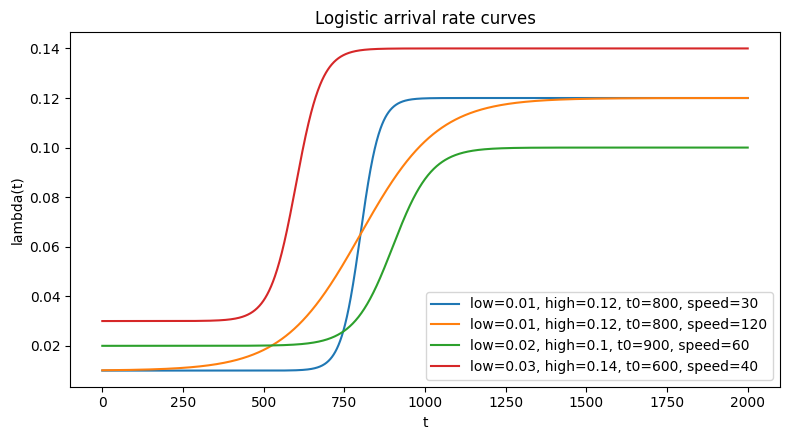

In [8]:
import matplotlib.pyplot as plt

T = 2000.0
ts = np.linspace(0, T, 2001)

configs = [
    dict(low=0.01, high=0.12, t0=800,  speed=30),
    dict(low=0.01, high=0.12, t0=800,  speed=120),
    dict(low=0.02, high=0.10, t0=900,  speed=60),
    dict(low=0.03, high=0.14, t0=600,  speed=40),
]

plt.figure(figsize=(8, 4.5))
for cfg in configs:
    lam = logistic_lambda(**cfg)
    plt.plot(ts, lam(ts),
             label=f"low={cfg['low']}, high={cfg['high']}, t0={cfg['t0']}, speed={cfg['speed']}")

plt.xlabel("t")
plt.ylabel("lambda(t)")
plt.title("Logistic arrival rate curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.sim_mm1 import mm1_sim

# config
T = 20000.0
lambda_t = logistic_lambda(low=0.02, high=0.09, t0=8000.0, speed=400.0)
mu = 0.10
mu_t = lambda t: mu

# bounds for thinning
lmax  = 1.05 * lmax_over_window(lambda_t, 0.0, T)
mumax = mu

# simulate
times, Q = mm1_sim(T, lambda_t, mu_t, lmax=lmax, mumax=mumax, init=0)

# optional: sample onto a regular grid
grid = np.linspace(0, T, 2001)
idx = np.searchsorted(times, grid, side="right") - 1
idx = np.clip(idx, 0, len(Q) - 1)
Q_grid = np.asarray([Q[i] for i in idx], dtype=int)

# quick plots
plt.figure(figsize=(10,4))
plt.step(times, Q, where="post")
plt.xlabel("time"); plt.ylabel("Q(t)")
plt.title("M_t/M/1 queue length (event times)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,3))
plt.plot(grid, Q_grid, lw=1)
plt.xlabel("time"); plt.ylabel("Q(t) on grid")
plt.title("Resampled onto regular grid")
plt.tight_layout(); plt.show()

TypeError: jackson_sim() got an unexpected keyword argument 'lambda_list'